In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
ethiopia = pd.read_csv("/home/samri/climate-challenge-week0/data/ethiopia_clean.csv")
kenya = pd.read_csv("/home/samri/climate-challenge-week0/data/kenya_clean.csv")
nigeria = pd.read_csv("/home/samri/climate-challenge-week0/data/nigeria_clean.csv")
sudan = pd.read_csv("/home/samri/climate-challenge-week0/data/sudan_clean.csv")
tanzania = pd.read_csv("/home/samri/climate-challenge-week0/data/Tanzania_clean.csv")

In [8]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
nigeria["Country"] = "Nigeria"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"

In [9]:
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania], ignore_index=True)

Temperature Trend Comparison

In [10]:
#Monthly average temperature
temp_trend = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()

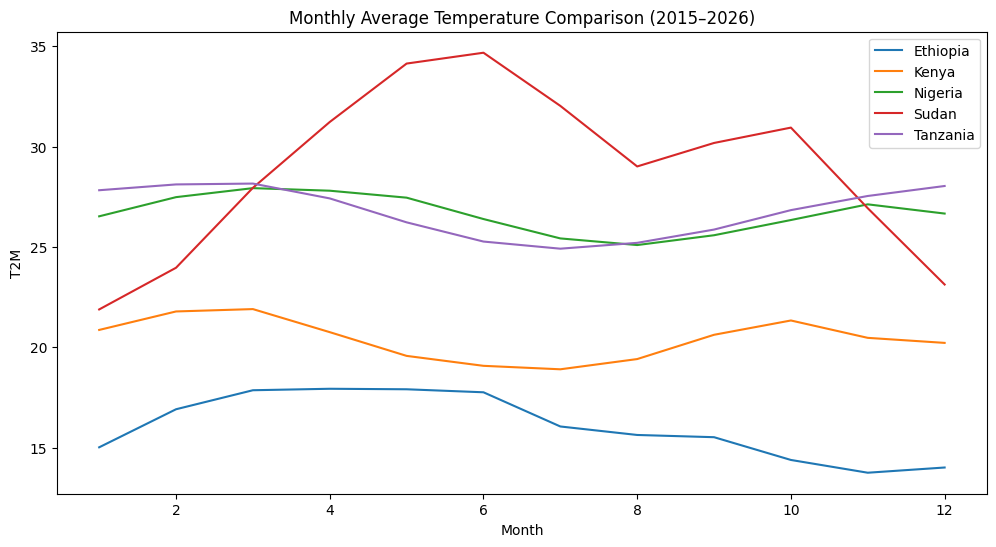

In [11]:
plt.figure(figsize=(12,6))

for c in df["Country"].unique():
    data = temp_trend[temp_trend["Country"] == c]
    plt.plot(data["Month"], data["T2M"], label=c)

plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.xlabel("Month")
plt.ylabel("T2M")
plt.legend()
plt.show()

In [12]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.069557,16.04,1.897073
Kenya,20.427811,20.36,1.440936
Nigeria,26.657275,26.82,1.123251
Sudan,28.759878,29.16,4.681542
Tanzania,26.802238,26.99,1.325497


Precipitation Variability Comparison

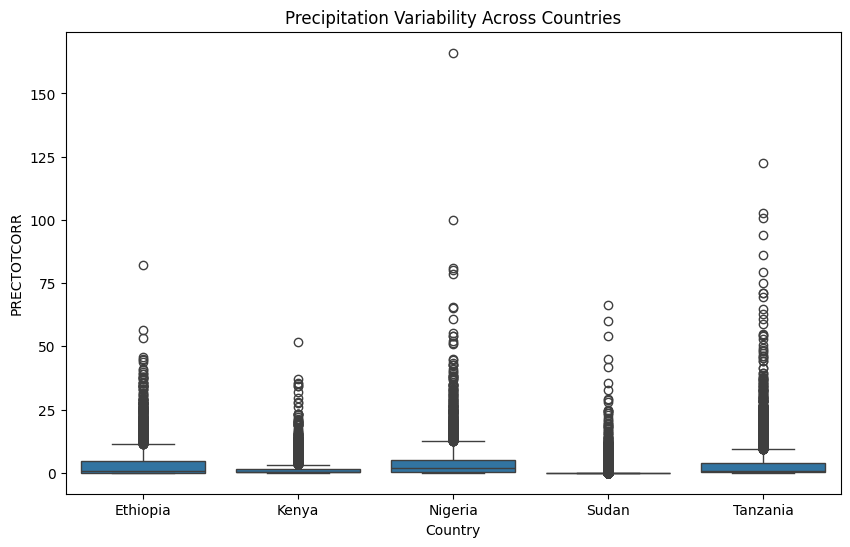

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Precipitation Variability Across Countries")
plt.show()

In [14]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.634680,0.82,6.289571
Kenya,1.468520,0.38,3.180533
Nigeria,4.214940,1.84,7.267329
Sudan,0.644032,0.00,3.058028
Tanzania,3.739403,0.64,8.004735


Extreme Event Frequency

In [15]:
heat_extremes = df[df["T2M_MAX"] > 35].groupby("Country").size()
heat_extremes

Country
Sudan    2693
dtype: int64

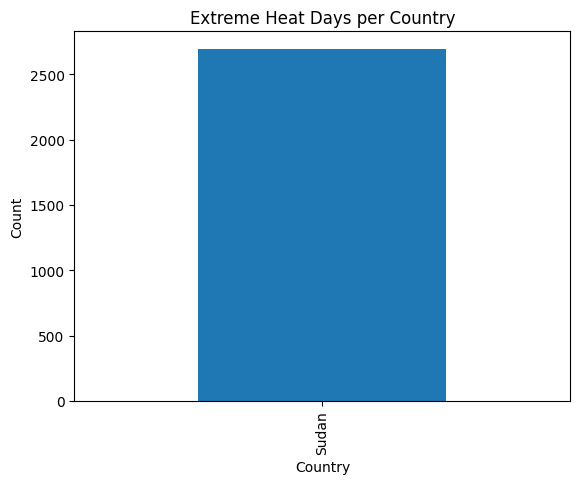

In [16]:
heat_extremes.plot(kind="bar")
plt.title("Extreme Heat Days per Country")
plt.ylabel("Count")
plt.show()

Dry days (<1 mm rainfall)

In [17]:
dry_days = df[df["PRECTOTCORR"] < 1].groupby("Country").size()
dry_days

Country
Ethiopia    2160
Kenya       2830
Nigeria     1594
Sudan       3695
Tanzania    2303
dtype: int64

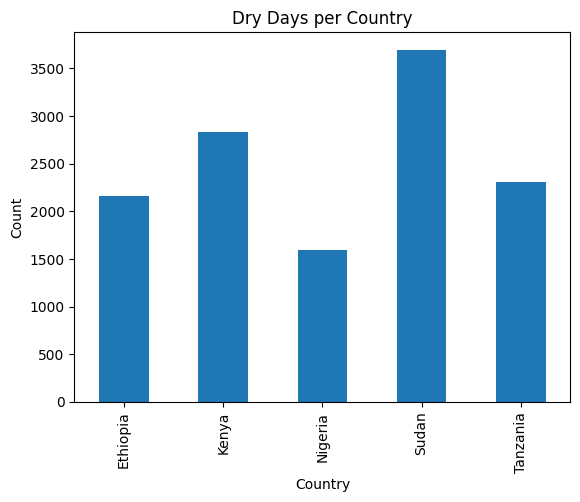

In [18]:
dry_days.plot(kind="bar")
plt.title("Dry Days per Country")
plt.ylabel("Count")
plt.show()

Statistical Testing (ANOVA)

In [19]:
#Temperature differences

from scipy.stats import f_oneway

groups = [df[df["Country"] == c]["T2M"].dropna() for c in df["Country"].unique()]

anova_result = f_oneway(*groups)
anova_result

F_onewayResult(statistic=18933.45954271451, pvalue=0.0)

Interprtation 


The one-way ANOVA test shows a statistically significant difference in mean temperature across the five countries (F = 18933.46, p < 0.001). This indicates that temperature patterns vary strongly between countries, confirming the presence of distinct climate zones rather than a uniform regional climate.

Climate Vulnerability Ranking

In [20]:
ranking = pd.DataFrame(index=temp_summary.index)

In [21]:
ranking["Mean Temp"] = temp_summary["mean"]
ranking["Rain Variability"] = rain_summary["std"]
ranking["Heat Extremes"] = heat_extremes
ranking["Dry Days"] = dry_days

In [22]:
ranking = ranking.fillna(0)

In [23]:
ranking["Vulnerability Score"] = (
    ranking["Mean Temp"] +
    ranking["Rain Variability"] +
    ranking["Heat Extremes"] +
    ranking["Dry Days"]
)

In [24]:
ranking = ranking.sort_values("Vulnerability Score", ascending=False)
ranking

,Mean Temp,Rain Variability,Heat Extremes,Dry Days,Vulnerability Score
Country,,,,,
Sudan,28.759878,3.058028,2693.0,3695,6419.817906
Kenya,20.427811,3.180533,0.0,2830,2853.608344
Tanzania,26.802238,8.004735,0.0,2303,2337.806973
Ethiopia,16.069557,6.289571,0.0,2160,2182.359128
Nigeria,26.657275,7.267329,0.0,1594,1627.924605


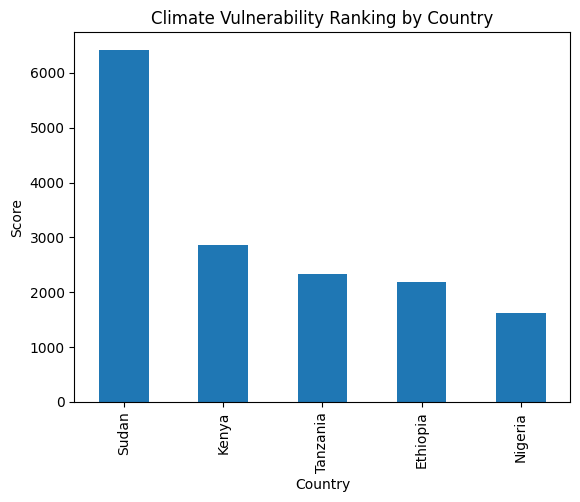

In [25]:
ranking["Vulnerability Score"].plot(kind="bar")
plt.title("Climate Vulnerability Ranking by Country")
plt.ylabel("Score")
plt.show()

The vulnerability score combines temperature intensity, rainfall variability, heat extremes, and dry day frequency. Countries with higher scores experience more severe climate stress due to a combination of heat, drought, and unstable precipitation patterns.

The ranking shows clear differences in climate risk exposure across countries, highlighting that some regions face significantly higher environmental stress than others.